# Implementação da regressão linear múltipla

## Importações iniciais

In [108]:
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import matplotlib.pyplot as plt
from sklearn.datasets import fetch_california_housing, load_diabetes
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error

## Implementação bruta

### Funções

In [109]:
def gradiente(X: np.ndarray, y: np.ndarray, learning_rate: float, iteracoes: int) -> tuple[np.ndarray, float, list]:
    m, n = X.shape

    y = y.reshape(m, 1)

    w = np.zeros((n, 1))
    b = 0.0
    historico_custo = []

    for _ in range(iteracoes):
        y_hat = np.dot(X, w) + b
        erro = y_hat - y

        custo = (1 / (2 * m)) * np.sum(erro ** 2)
        historico_custo.append(custo)

        dw = (1 / m) * np.dot(X.T, erro)
        db = (1 / m) * np.sum(erro)

        w -= learning_rate * dw
        b -= learning_rate * db

    return w.flatten(), float(b), historico_custo

### Classes

In [110]:
# Classe do modelo de regressão linear
class LinearReg:
    def __init__(self, learning_rate:float, iteracoes:int):
        self.learning_rate = learning_rate
        self.iteracoes = iteracoes
        self.w = None
        self.b = None
        self.historico_custo = []
    def fit(self,X:pd.DataFrame,y:pd.Series) -> None:
        X_np = X.to_numpy() if isinstance(X, pd.DataFrame) else X
        y_np = y.to_numpy().ravel() if isinstance(y, (pd.Series, pd.DataFrame)) else y.ravel()
        self.w, self.b, self.historico_custo = gradiente(X_np, y_np, self.learning_rate, self.iteracoes)
    def predict(self,X:pd.DataFrame)->np.ndarray:
        return np.dot(X, self.w) + self.b
    def MSE(self,y_true:pd.Series,y_pred:np.ndarray)->float:
        m = len(y_true)
        return (1/m) * np.sum((y_true - y_pred) ** 2)

## Implementação usando pytorch

### Funções

In [111]:
def TensorConverter(X:pd.DataFrame,y:pd.Series)->tuple[torch.Tensor,torch.Tensor]:
    X_tensor = torch.tensor(X, dtype=torch.float32)
    y_tensor = torch.tensor(y, dtype=torch.float32).view(-1, 1)
    return X_tensor, y_tensor

### Classes

In [112]:
# Classe do modelo de regressão linear usando pytorch
class LinearRegTorch(nn.Module):
    def __init__(self, learning_rate: float = 1e-3, iteracoes: int = 1000):
        super(LinearRegTorch, self).__init__()
        self.learning_rate = learning_rate
        self.iteracoes = iteracoes
        self.historico_custo = []
        self.linear = None
        self.criterion = nn.MSELoss()
    def forward(self, x: torch.Tensor) -> torch.Tensor:
        return self.linear(x)
    def fit(self, X: pd.DataFrame, y: pd.Series) -> None:
        X_tensor, y_tensor = TensorConverter(X, y)
        n_features = X.shape[1]
        self.linear = nn.Linear(n_features, 1)
        optimizer = torch.optim.SGD(self.parameters(), lr=self.learning_rate)
        self.historico_custo = []
        self.train()
        for _ in range(self.iteracoes):
            optimizer.zero_grad()
            y_hat = self.forward(X_tensor)
            loss = self.criterion(y_hat, y_tensor)
            loss.backward()
            optimizer.step()
            self.historico_custo.append(loss.item())
    def predict(self, X: pd.DataFrame, y: pd.Series | None = None) -> np.ndarray:
        self.eval()
        with torch.no_grad():
            dummy_y = pd.Series(np.zeros(len(X)))
            X_tensor, _ = TensorConverter(X, y if y is not None else dummy_y)
            y_hat = self.forward(X_tensor)
            return y_hat.numpy().flatten()
    def MSE(self, y_true: pd.Series | np.ndarray, y_pred: np.ndarray) -> float:
        y_t = y_true.to_numpy().ravel() if isinstance(y_true, (pd.Series, pd.DataFrame)) else y_true.ravel()
        return float(np.mean((y_t - y_pred) ** 2))
    @property
    def w(self) -> np.ndarray | None:
        if self.linear is not None:
            return self.linear.weight.detach().numpy().flatten()
        return None
    @property
    def b(self) -> float | None:
        if self.linear is not None:
            return float(self.linear.bias.detach().numpy()[0])
        return None

## Implementação usando scikit-learn

Como o scikit learn já implementa a regressão linear com o gradiente descendente (só que o estocástico), então basta importar.

In [113]:
from sklearn.linear_model import SGDRegressor

# Testes

## Preparando dataset

In [114]:
X = fetch_california_housing(as_frame=True).frame
y = X["MedHouseVal"]
X.drop("MedHouseVal", axis=1, inplace=True)

In [115]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=0)

In [116]:
mean_X, std_X = X_train.mean(), X_train.std() #Z-score
X_train = ((X_train - mean_X) / std_X).to_numpy()
X_test = ((X_test - mean_X) / std_X).to_numpy()

In [117]:
y_train = y_train.to_numpy()
y_test = y_test.to_numpy()

## Teste com a implementação bruta

### Teste com $\alpha=0.01$

In [118]:
linear_reg = LinearReg(learning_rate=0.01, iteracoes=500)

In [119]:
linear_reg.fit(X_train, y_train)

In [120]:
y_pred = linear_reg.predict(X_test)

In [121]:
mse = linear_reg.MSE(y_test, y_pred)

In [122]:
mse

np.float64(0.6068298652780899)

In [123]:
historico_alpha001 = linear_reg.historico_custo

### Teste com $\alpha=0.1$

In [124]:
linear_reg = LinearReg(learning_rate=0.1, iteracoes=500)

In [125]:
linear_reg.fit(X_train, y_train)

In [126]:
y_pred = linear_reg.predict(X_test)

In [127]:
mse = linear_reg.MSE(y_test, y_pred)

In [128]:
mse

np.float64(0.5443311310624165)

In [129]:
historico_alpha01 = linear_reg.historico_custo

### Teste com $\alpha=0.5$

In [130]:
linear_reg = LinearReg(learning_rate=0.5, iteracoes=500)

In [131]:
linear_reg.fit(X_train, y_train)

In [132]:
y_pred = linear_reg.predict(X_test)

In [133]:
mse = linear_reg.MSE(y_test, y_pred)

In [134]:
mse

np.float64(0.5431490783147186)

In [135]:
historico_alpha05 = linear_reg.historico_custo

### Teste com $\alpha=0.05$

In [136]:
linear_reg = LinearReg(learning_rate=0.05, iteracoes=500)

In [137]:
linear_reg.fit(X_train, y_train)

In [138]:
y_pred = linear_reg.predict(X_test)

In [139]:
mse = linear_reg.MSE(y_test, y_pred)

In [140]:
mse

np.float64(0.5489974238864057)

In [141]:
historico_alpha005 = linear_reg.historico_custo

### Gráficos pra diferentes valores de alpha

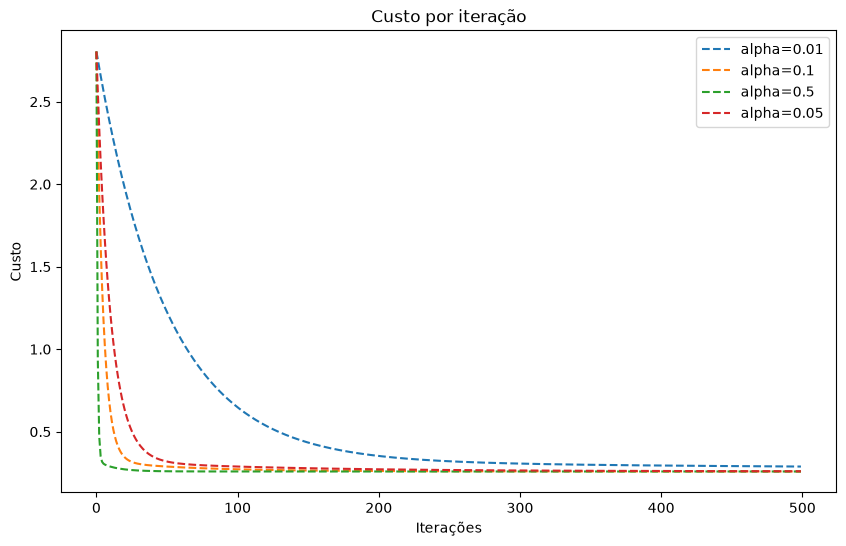

In [142]:
plt.figure(figsize=(10,6))
plt.title("Custo por iteração")
plt.xlabel("Iterações")
plt.ylabel("Custo")
plt.plot(historico_alpha001, label="alpha=0.01",linestyle="--")
plt.plot(historico_alpha01, label="alpha=0.1",linestyle="--")
plt.plot(historico_alpha05,label="alpha=0.5",linestyle="--")
plt.plot(historico_alpha005,label="alpha=0.05",linestyle="--")
plt.legend()
plt.show()

Análise breve do comportamento da função de perda $L$:
- O $\alpha$ que levou a convergência mais rapidamente foi $\alpha=0.5$.
- $\alpha=0.01$ obteve a convergência mais lenta e o maior MSE.

## Testes com a implementação usando pytorch

### Teste com $\alpha=0.01$

In [143]:
linear_reg = LinearRegTorch(learning_rate=0.01,iteracoes=500)

In [144]:
linear_reg.fit(X_train,y_train)

In [145]:
y_pred = linear_reg.predict(X_test)

In [146]:
mse = linear_reg.MSE(y_test,y_pred)

In [147]:
mse

0.5694845450423365

In [148]:
historico_alpha001 = linear_reg.historico_custo

### Teste com $\alpha=0.1$

In [149]:
linear_reg = LinearRegTorch(learning_rate=0.1,iteracoes=500)

In [150]:
linear_reg.fit(X_train,y_train)

In [151]:
y_pred = linear_reg.predict(X_test)

In [152]:
mse = linear_reg.MSE(y_test,y_pred)

In [153]:
mse

0.5432923845783962

In [154]:
historico_alpha01 = linear_reg.historico_custo

### Testes com $\alpha=0.25$

In [155]:
linear_reg = LinearRegTorch(learning_rate=0.25,iteracoes=500)

In [156]:
linear_reg.fit(X_train,y_train)

In [157]:
y_pred = linear_reg.predict(X_test,y_test)

In [158]:
mse = linear_reg.MSE(y_test,y_pred)

In [159]:
mse

0.5431491268019454

In [160]:
historico_alpha025 = linear_reg.historico_custo

### Testes com $\alpha=0.05$

In [161]:
linear_reg = LinearRegTorch(learning_rate=0.05,iteracoes=500)

In [162]:
linear_reg.fit(X_train,y_train)

In [163]:
y_pred = linear_reg.predict(X_test)

In [164]:
mse = linear_reg.MSE(y_test,y_pred)

In [165]:
mse

0.543686680689957

In [166]:
historico_alpha005 = linear_reg.historico_custo

### Gráficos pra diferentes valores de alpha

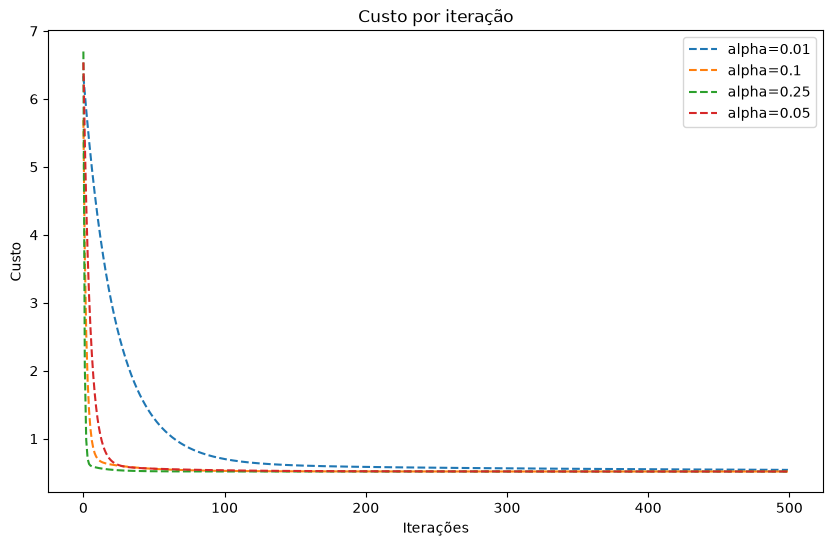

In [167]:
plt.figure(figsize=(10,6))
plt.title("Custo por iteração")
plt.xlabel("Iterações")
plt.ylabel("Custo")
plt.plot(historico_alpha001, label="alpha=0.01",linestyle="--")
plt.plot(historico_alpha01, label="alpha=0.1",linestyle="--")
plt.plot(historico_alpha025,label="alpha=0.25",linestyle="--")
plt.plot(historico_alpha005,label="alpha=0.05",linestyle="--")
plt.legend()
plt.show()

## Testes com a implementação usando scikit-learn

A preguiça bateu

In [172]:
def loop_sgd(model: SGDRegressor, iteracoes: int, X_train: np.ndarray, y_train: np.ndarray, batch_size: int = 16) -> list[float]:
    historico = []
    n_samples = len(X_train)
    
    for i in range(iteracoes):
        idx_inicio = (i * batch_size) % n_samples
        idx_fim = idx_inicio + batch_size
        
        X_batch = X_train[idx_inicio:idx_fim]
        y_batch = y_train[idx_inicio:idx_fim]
        
        model.partial_fit(X_batch, y_batch)
        
        y_pred = model.predict(X_train)
        custo = mean_squared_error(y_train, y_pred) / 2
        historico.append(custo)
        
    return historico

In [173]:
alpha = [0.01, 0.05, 0.1,0.5]
historico = []

In [174]:
for a in alpha:
    linear_reg = SGDRegressor(
        loss="squared_error",
        penalty=None,
        learning_rate="constant",
        eta0=a,
        random_state=0
    )
    historico.append((a, loop_sgd(linear_reg, 500, X_train, y_train, batch_size=16)))

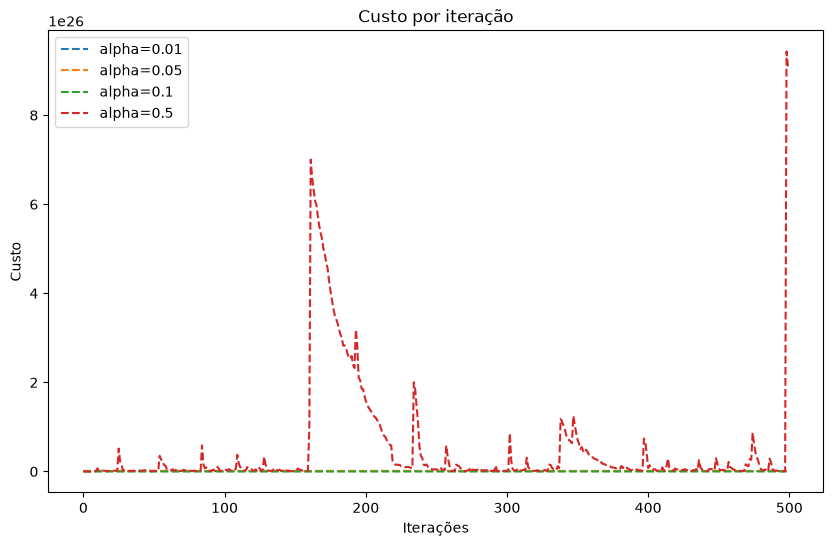

In [175]:
plt.figure(figsize=(10, 6))
plt.title("Custo por iteração")
plt.xlabel("Iterações")
plt.ylabel("Custo")

for a, h in historico:
    plt.plot(h, label=f"alpha={a}", linestyle="--")

plt.legend()
plt.show()

Como o gradiente descendente do scikit-learn é estocástico, então o valor da função de perda a cada iteração não é linear, muito menos monótono, então nem sempre vale que $L_{(n)}<L_{(n+1)}$, então ele fica bem imprevisível desse jeito mesmo.